In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib
matplotlib.rcParams['pdf.use14corefonts'] = True


ERROR: Error in parse(text = input): <text>:2:8: unexpected symbol
1: # Import libraries
2: import pandas
          ^


In [2]:
# Set the working directory
os.chdir('/scratch/mjehangir/manuscript_figures/figures')

ERROR: Error in os.chdir("/scratch/mjehangir/manuscript_figures/figures"): could not find function "os.chdir"


/tmp/ipykernel_1196177/3295055468.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cnv_count = data.groupby(["chrom", "ID"])["CNV_Type"].count().unstack(fill_value=0)
/tmp/ipykernel_1196177/3295055468.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cnv_proportion = data.groupby(["chrom", "ID"])["CNV_Proportion"].sum().unstack(fill_value=0)
/tmp/ipykernel_1196177/3295055468.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence th

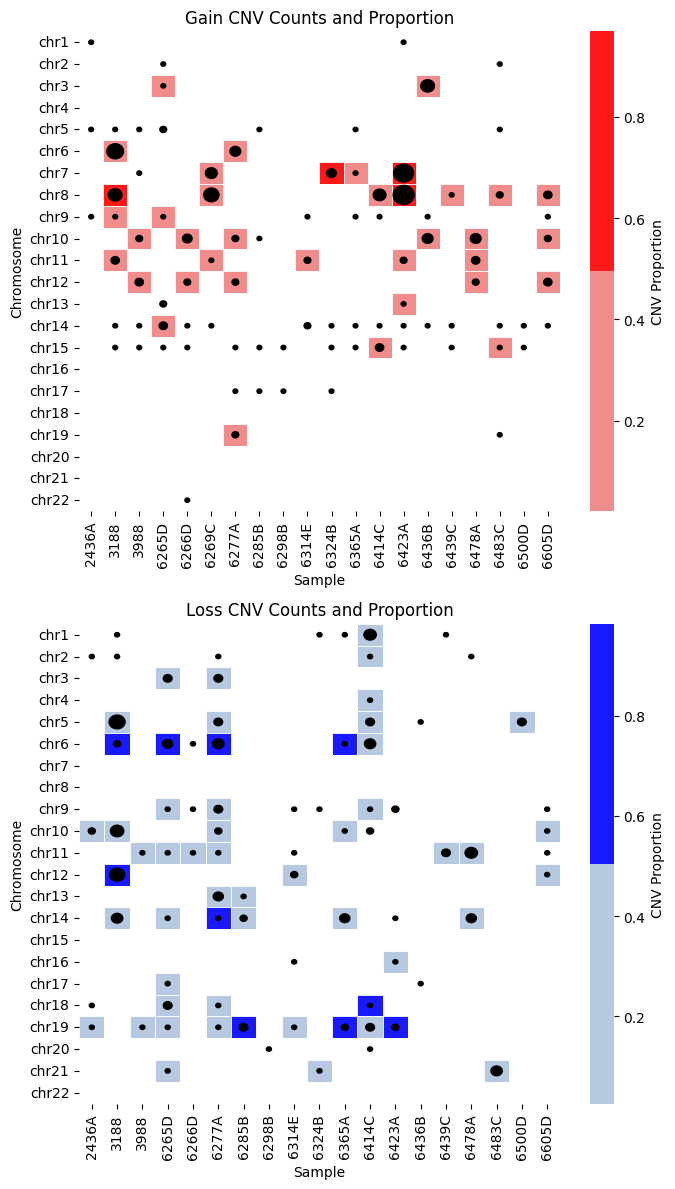

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.colors as mcolors
matplotlib.rcParams['pdf.use14corefonts'] = True
# Chromosome size information for CHM13 genome
chromosome_sizes = {
    "chr1": 248956422, "chr2": 242193529, "chr3": 198295559, "chr4": 190214555,
    "chr5": 181538259, "chr6": 170805979, "chr7": 159345973, "chr8": 145138636,
    "chr9": 138394717, "chr10": 133797422, "chr11": 135086622, "chr12": 133275309,
    "chr13": 114364328, "chr14": 107043718, "chr15": 101991189, "chr16": 90338345,
    "chr17": 83257441, "chr18": 80373285, "chr19": 58617616, "chr20": 64444167,
    "chr21": 46709983, "chr22": 50818468,
}

# Load data
file_path = 'mean_centered_normalization_segmentation_v2.seg'
data = pd.read_csv(file_path, sep="\t")

# Sort chromosomes numerically based on the order in chromosome_sizes
chromosome_order = list(chromosome_sizes.keys())
data["chrom"] = pd.Categorical(data["chrom"], categories=chromosome_order, ordered=True)
data.sort_values("chrom", inplace=True)

# Determine CNV Type: 'Gain', 'Loss', or 'Neutral'
data["CNV_Type"] = data["seg.mean"].apply(lambda x: "Gain" if x > 1.3 else ("Loss" if x < 0.4 else "Neutral"))

# Calculate CNV Size
data["CNV_Size"] = data["loc.end"] - data["loc.start"]

# Calculate CNV proportion per sample and chromosome
data["CNV_Proportion"] = data["CNV_Size"] / data["chrom"].astype(str).map(chromosome_sizes)

# Step 1: Calculate CNV count per sample and chromosome
cnv_count = data.groupby(["chrom", "ID"])["CNV_Type"].count().unstack(fill_value=0)

# Step 2: Aggregate CNV proportion by sample and chromosome
cnv_proportion = data.groupby(["chrom", "ID"])["CNV_Proportion"].sum().unstack(fill_value=0)

# Set a threshold for CNV proportion to be considered white (e.g., 0.03)
threshold = 0.02

# Step 3: Mask values below the threshold as NaN to show them as white
masked_cnv_proportion = cnv_proportion.copy()
masked_cnv_proportion[masked_cnv_proportion < threshold] = np.nan

# Separate data for "Gain" and "Loss"
data_gain = data[data["CNV_Type"] == "Gain"]
data_loss = data[data["CNV_Type"] == "Loss"]

# Calculate CNV counts and proportions for Gain and Loss separately
cnv_count_gain = data_gain.groupby(["chrom", "ID"])["CNV_Type"].count().unstack(fill_value=0)
cnv_count_loss = data_loss.groupby(["chrom", "ID"])["CNV_Type"].count().unstack(fill_value=0)

cnv_proportion_gain = data_gain.groupby(["chrom", "ID"])["CNV_Proportion"].sum().unstack(fill_value=0)
cnv_proportion_loss = data_loss.groupby(["chrom", "ID"])["CNV_Proportion"].sum().unstack(fill_value=0)

# Mask CNV proportion for Gain and Loss
masked_cnv_proportion_gain = cnv_proportion_gain.copy()
masked_cnv_proportion_loss = cnv_proportion_loss.copy()

masked_cnv_proportion_gain[masked_cnv_proportion_gain < threshold] = np.nan
masked_cnv_proportion_loss[masked_cnv_proportion_loss < threshold] = np.nan

# Create a function to plot and save the heatmap as PDF
def plot_cnv_heatmap(cnv_proportion_data, cnv_count_data, ax, plot_title, cmap, alpha=0.7):
    sns.heatmap(cnv_proportion_data, cmap=cmap, annot=False, fmt=".2f", linewidths=.5,
                cbar_kws={'label': 'CNV Proportion'}, alpha=alpha, ax=ax)

    # Overlay circles to represent CNV counts (circle size reflects the count)
    for i in range(cnv_proportion_data.shape[0]):
        for j in range(cnv_proportion_data.shape[1]):
            count = cnv_count_data.iloc[i, j]
            if count > 0:  # Only plot a circle if there is a CNV count
                # Scale circle size to fit within the matrix cell
                circle_size = np.sqrt(count) * 0.1  # Adjust the factor (0.1) to scale appropriately
                # Plot circle at position (j, i) in axes coordinates (x, y)
                ax.add_patch(plt.Circle((j + 0.5, i + 0.5), radius=circle_size, color="black", linewidth=1, alpha=1))

    ax.set_title(plot_title)
    ax.set_xlabel('Sample')
    ax.set_ylabel('Chromosome')

# Custom colormap for Gain (red) and Loss (blue)
gain_cmap = mcolors.ListedColormap(["lightcoral", "red"])
loss_cmap = mcolors.ListedColormap(["lightsteelblue", "blue"])

# Define file path for saving the heatmap as PDF
#save_path = '/scratch/mjehangir/heatmap_gain_loss_cnv.pdf'

# Create a figure with subplots (2 rows and 1 column)
fig, axes = plt.subplots(2, 1, figsize=(7, 12))  # Adjust figsize for side-by-side plots

# Plot and save both heatmaps in one figure
plot_cnv_heatmap(masked_cnv_proportion_gain, cnv_count_gain, axes[0], 'Gain CNV Counts and Proportion', gain_cmap, alpha=0.9)
plot_cnv_heatmap(masked_cnv_proportion_loss, cnv_count_loss, axes[1], 'Loss CNV Counts and Proportion', loss_cmap, alpha=0.9)


# Adjust layout to make sure everything fits
plt.tight_layout()

# Save the entire figure as a PDF
#plt.savefig(save_path, format='pdf')
plt.show()
# Close the plot to free up memory
plt.close()
